<a href="https://colab.research.google.com/github/samarthboraste/customer-churn-prediction/blob/main/Customer_Churn_Random_forest.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [134]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings('ignore')

In [135]:
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder
from sklearn import *
from sklearn.metrics import recall_score,confusion_matrix,precision_score
from sklearn.ensemble import RandomForestClassifier

In [198]:
df=pd.read_csv('customer_churn.csv')
df_readable = df.copy()
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


**So, In this Telecom Company's Data we have,**
*  **Churn Column** - *Customers who left recently*

* **Services provided by the company to its customer** – *phone, multiple lines, internet, online security, online backup, device protection, tech support, and streaming TV and movies*

* **Customer's Information Columns** - *Old/New Customer and their Active Period, contract, payment method, paperless billing, monthly charges, and total charges*

* **Customer's Demographic Columns** – *gender, age range, and if they have partners and dependents*

In [138]:
df.shape

(7043, 21)

In [139]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


##  Dataset Inference and Understanding

### 1. Overview
- The dataset contains **7043 rows** and **21 columns**.
- It appears to represent **customer information for a telecommunications company**, where the target variable **`Churn`** indicates whether a customer has discontinued the service.
- **Memory usage:** ~1.1 MB

---

###  2. Column Details

| Type | Count | Example Columns |
|------|--------|----------------|
| **Object (categorical)** | 18 | `customerID`, `gender`, `Partner`, `Dependents`, `PhoneService`, `MultipleLines`, `InternetService`, `OnlineSecurity`, `OnlineBackup`, `DeviceProtection`, `TechSupport`, `StreamingTV`, `StreamingMovies`, `Contract`, `PaperlessBilling`, `PaymentMethod`, `TotalCharges`, `Churn` |
| **Integer (numeric)** | 2 | `SeniorCitizen`, `tenure` |
| **Float (numeric)** | 1 | `MonthlyCharges` |

- Most features are **categorical** — describing customer demographics and services used.
- Only a few are **numerical**: `tenure`, `MonthlyCharges`, and (after conversion) `TotalCharges`.

---

###  3. Data Quality Observations

1. **`TotalCharges` column:**
   - Currently stored as an `object` (string), even though it represents numerical values.
   - This means there might be some invalid or missing entries (like blank spaces).

2. **No visible missing values** in the info summary (`non-null count = 7043`),  
   but hidden missing or invalid entries may exist in `TotalCharges`.

3. **`customerID`** is a unique identifier for each customer and should not be used for model training.

In [140]:
#therefore removing the customerID column
df=df.drop(['customerID'],axis=1)

In [141]:
df['TotalCharges']=pd.to_numeric(df['TotalCharges'],errors='coerce')

In [142]:
df.isna().sum()

,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0
OnlineBackup,0


In [143]:
#now we have 11 null values in out data set of TotalCharges so to handle them
#we can multiplt tenure and monthlycharges to get the totalcharges
#first doing an important step deleting all data with tenure=0
#because we dont want that people right who have never used our services why to keep them in churn

In [144]:
df.drop(labels=df[df['tenure']==0].index,inplace=True)

In [145]:
#now checking the null values again
df.isna().sum()

,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0
OnlineBackup,0


In [146]:
#magic our totalcharges column's null values automatically got 0
df.shape

(7032, 20)

In [147]:
df.isna().sum().sum()

np.int64(0)

In [148]:
df.duplicated().sum()

np.int64(22)

you can also write df.TotalCharges instead of df['TotalCharges'] both means the same

In [149]:
df['TotalCharges']

,TotalCharges
0,29.85
1,1889.50
2,108.15
3,1840.75
4,151.65
...,...
7038,1990.50
7039,7362.90
7040,346.45
7041,306.60


In [150]:
#now if u see SeniorCitizen column it has 0,1 as yes or no which doesnt look good hence
#mapping/replacing it with yes or no

In [151]:
df['SeniorCitizen']=df['SeniorCitizen'].map({0: "no",1: "yes"})

In [152]:
df.describe()

,tenure,MonthlyCharges,TotalCharges
count,7032.000000,7032.000000,7032.000000
mean,32.421786,64.798208,2283.300441
std,24.545260,30.085974,2266.771362
min,1.000000,18.250000,18.800000
25%,9.000000,35.587500,401.450000
50%,29.000000,70.350000,1397.475000
75%,55.000000,89.862500,3794.737500
max,72.000000,118.750000,8684.800000


In [153]:
df.describe(include='O')

,gender,SeniorCitizen,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Churn
count,7032,7032,7032,7032,7032,7032,7032,7032,7032,7032,7032,7032,7032,7032,7032,7032,7032
unique,2,2,2,2,2,3,3,3,3,3,3,3,3,3,2,4,2
top,Male,no,No,No,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,No
freq,3549,5890,3639,4933,6352,3385,3096,3497,3087,3094,3472,2809,2781,3875,4168,2365,5163


In [154]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
gender,7032,2,Male,3549,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SeniorCitizen,7032,2,no,5890,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Partner,7032,2,No,3639,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Dependents,7032,2,No,4933,NaN,NaN,NaN,NaN,NaN,NaN,NaN
tenure,7032.0,NaN,NaN,NaN,32.421786,24.54526,1.0,9.0,29.0,55.0,72.0
PhoneService,7032,2,Yes,6352,NaN,NaN,NaN,NaN,NaN,NaN,NaN
MultipleLines,7032,3,No,3385,NaN,NaN,NaN,NaN,NaN,NaN,NaN
InternetService,7032,3,Fiber optic,3096,NaN,NaN,NaN,NaN,NaN,NaN,NaN
OnlineSecurity,7032,3,No,3497,NaN,NaN,NaN,NaN,NaN,NaN,NaN
OnlineBackup,7032,3,No,3087,NaN,NaN,NaN,NaN,NaN,NaN,NaN


###  **General Overview**

* **Total customers:** 7,032
* **Target variable:** `Churn` (Yes/No) → 5163 “No” and 1869 “Yes” (≈ 26.6% churn rate).
  → So, around **one in four customers churned**.

---

### **Demographics**

* **Gender:** Fairly balanced — 3,549 male and 3,483 female customers.
* **Senior Citizens:** Only about 16% (`7032 - 5890 = 1142`) are seniors, suggesting a younger customer base overall.
* **Partner:** 51.7% of customers do **not** have a partner.
* **Dependents:** 70% (4,933) have **no dependents**, indicating mostly single or independent individuals.

---

###  **Tenure and Loyalty**

* **Tenure mean:** 32.4 months (≈ 2.7 years).
* **Range:** 1 to 72 months.
  → Many customers are relatively new, as the median tenure is just **29 months**.
* Customers with longer tenures likely show lower churn rates (based on typical telecom churn trends).

---

###  **Services and Features**

* **Phone Service:** Almost all customers (6,352) have it.
* **Multiple Lines:** About half have multiple lines.
* **Internet Service:**

  * Fiber optic: Most common (3,096 users).
  * DSL and No Internet are less frequent.
* **Online Security, Backup, Device Protection, Tech Support:**
  Most customers answered **“No”** to these — suggesting **low adoption of add-on services**.

---

###  **Entertainment Services**

* **Streaming TV/Movies:** Roughly equal mix between users and non-users, indicating streaming is a moderately adopted service.

---

###  **Contracts and Billing**

* **Contract Type:**

  * **Month-to-month:** Most common (3,875 customers).
  * The rest have one- or two-year contracts.
* **Paperless Billing:** 59% use it (`4168 Yes`).
* **Payment Method:**

  * **Electronic check** is most popular (2,365 users).
  * Other payment methods include mailed check, bank transfer, and credit card.

---

###  **Charges**

* **Monthly Charges:**

  * Mean = $64.80
  * Range = $18.25 – $118.75
  * Higher monthly charges often correspond to fiber optic users and those with multiple add-ons.
* **Total Charges:**

  * Mean = $2,283
  * Range = $18.80 – $8,684
  * Strongly influenced by tenure higher tenure = higher total charges.

---

###  **Key Insights**

1. **Churn is higher among**:

   * Month-to-month customers
   * Fiber optic users (higher cost, possibly performance or price dissatisfaction)
   * Customers with fewer add-on services (low perceived value)

2. **Retention is stronger among**:

   * Long-tenure customers
   * Those with longer contracts
   * Those using electronic or automatic payments

3. **Opportunities for the company:**

   * Encourage add-on adoption (security, tech support, etc.)
   * Convert short-term contracts to longer ones
   * Offer loyalty incentives to new customers in their first 1–2 years.


In [155]:
df.Churn.value_counts() #using different type of syntax :)

,count
Churn,
No,5163
Yes,1869


In [156]:
#saving copy of my data in df2
#changing Churn columns to numeric in 0 and 1 /you can also use the earlier mapping technique for short
df2 = df.copy()
df2['Churn'] = df2['Churn'].replace({'Yes': 1, 'No': 0})

In [157]:
df2 #see changes

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,no,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,Male,no,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0
2,Male,no,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
3,Male,no,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0
4,Female,no,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,Male,no,Yes,Yes,24,Yes,Yes,DSL,Yes,No,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.50,0
7039,Female,no,Yes,Yes,72,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.90,0
7040,Female,no,Yes,Yes,11,No,No phone service,DSL,Yes,No,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,0
7041,Male,yes,Yes,No,4,Yes,Yes,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.60,1


In [158]:
df['gender'].value_counts()
 #There's almost to null differences between the people who churned
 #as both men and women are churn in equal ratio.

,count
gender,
Male,3549
Female,3483


In [159]:
df_dummies=pd.get_dummies(df2) #a function in pandas that converts categorical variables into dummy/indicator variables (one‑hot encoding).
df_dummies.head()

,tenure,MonthlyCharges,TotalCharges,Churn,gender_Female,gender_Male,SeniorCitizen_no,SeniorCitizen_yes,Partner_No,Partner_Yes,...,StreamingMovies_Yes,Contract_Month-to-month,Contract_One year,Contract_Two year,PaperlessBilling_No,PaperlessBilling_Yes,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,1,29.85,29.85,0,True,False,True,False,False,True,...,False,True,False,False,False,True,False,False,True,False
1,34,56.95,1889.50,0,False,True,True,False,True,False,...,False,False,True,False,True,False,False,False,False,True
2,2,53.85,108.15,1,False,True,True,False,True,False,...,False,True,False,False,False,True,False,False,False,True
3,45,42.30,1840.75,0,False,True,True,False,True,False,...,False,False,True,False,True,False,True,False,False,False
4,2,70.70,151.65,1,True,False,True,False,True,False,...,False,True,False,False,False,True,False,False,True,False


In [160]:
df_dummies.corr()['Churn'] #gives corr() matrix of column Churn from df_dummies

,Churn
tenure,-0.354049
MonthlyCharges,0.192858
TotalCharges,-0.199484
Churn,1.000000
gender_Female,0.008545
gender_Male,-0.008545
SeniorCitizen_no,-0.150541
SeniorCitizen_yes,0.150541
Partner_No,0.149982
Partner_Yes,-0.149982


<Axes: >

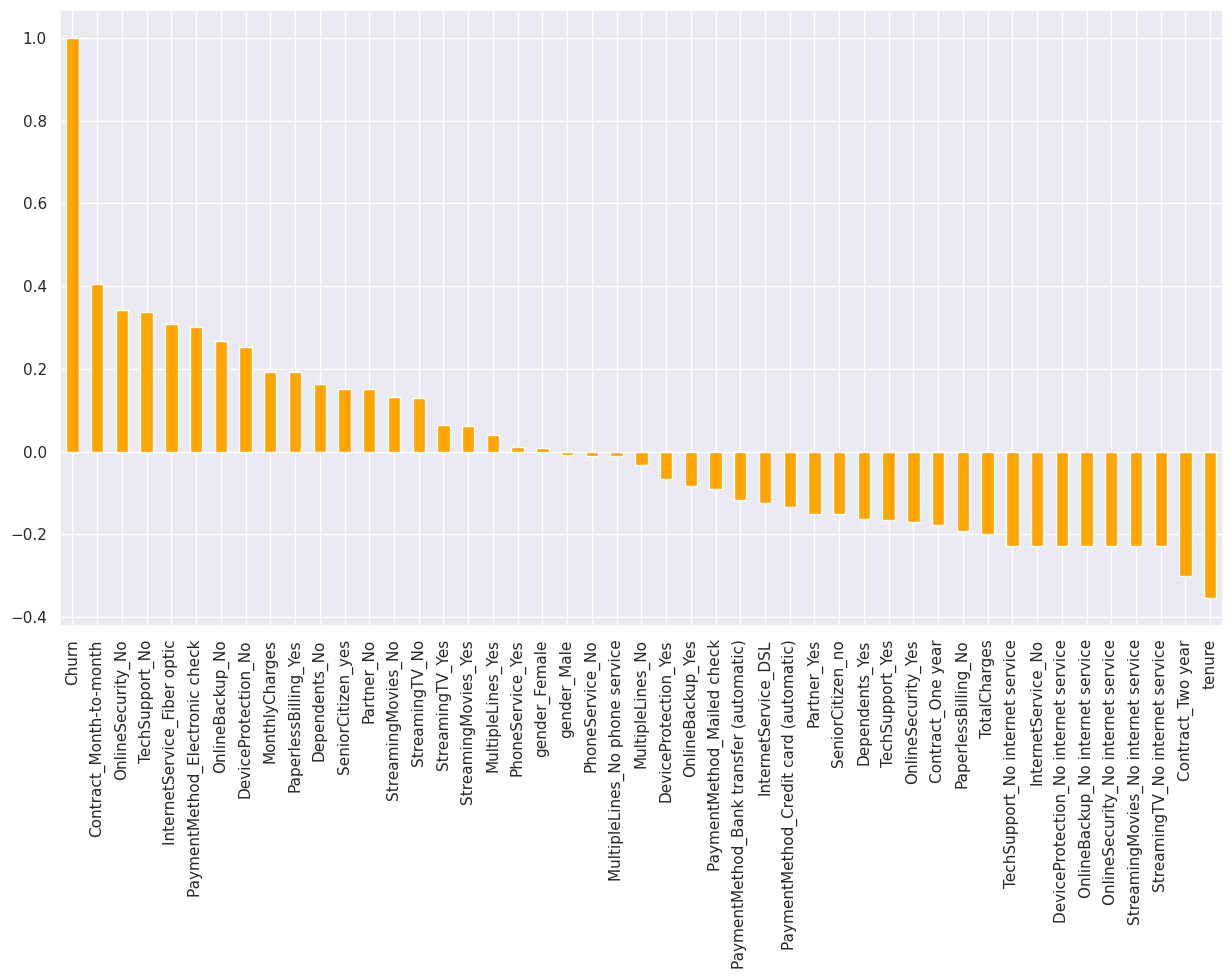

In [161]:
#plotting a graph of correlation of Churn with other features in ddf_dummies
plt.figure(figsize=(15,8))
sns.set(style='darkgrid') #bg type u can also do whitegrid,dark,white etc

df_dummies.corr()['Churn'].sort_values(ascending=False).plot(kind='bar',color='orange')

## **Visualizing the Data**

In [162]:
color_discrete_map={"Month-to-month":"#ffc0cb","One year":"#065535","Two year":"#ffd700"}
fig=px.histogram(df,x='Churn',color='Contract',barmode='group',title='<b>Churn Distribution wrt Contract<b>', color_discrete_map = color_discrete_map)
fig.update_layout(width=700,height=500,bargap=0.1)
fig.show()

##  Churn Distribution with respect to Contract Type

###  Chart Description
The bar chart shows how **customer churn** varies across different **contract types**.

- **X-axis:** Churn status  
  - `0` → Customers who stayed (did not churn)  
  - `1` → Customers who left (churned)
- **Y-axis:** Number of customers  
  

---

###  Key Observations

1. **Month-to-Month Contracts:**
   - The majority of churned customers (Churn = 1) are on **month-to-month** contracts.  
   - This indicates that customers without long-term commitments are **more likely to leave**.

2. **One-Year and Two-Year Contracts:**
   - Customers on **one-year** or **two-year** contracts have a **much lower churn rate**.
   - Long-term contracts seem to **increase customer retention**, likely due to stability, discounts, or contractual obligations.

3. **Churn Trend Summary:**
   - **Short-term (month-to-month)** → High churn rate.  
   - **Long-term (one or two years)** → Low churn rate.

---

###  Insights for Learners

- Contract duration has a **strong influence on customer loyalty**.
- Customers with flexible, month-to-month agreements can **easily switch to competitors**, leading to higher churn.
- Telecom companies can **reduce churn** by:
  - Offering **incentives** for longer contracts (discounts, bundles, loyalty programs).  
  - Improving **customer experience** for short-term users to encourage contract upgrades.

---

###  Summary
- **Month-to-month** customers → highest churn rate.  
- **One-year and two-year** customers → lowest churn rate.  
- Contract type is one of the **most important predictors** of customer churn.


* 75% of customer who have Month-to-Month Contract
have opted to move out as compared to 13% of customers  who have signed One Year Contract and 3% of customers  who have signed Two Year Contract.

In [163]:
fig = px.histogram(df, x="Churn", color="PaymentMethod", title="<b>Churn distribution w.r.t. Customer Payment Method</b>",text_auto=True)
fig.update_layout(width=700, height=500, bargap=0.1)
# fig.data[0].marker.color = ('#7fcdff')
# fig.data[1].marker.color = ('#326ada')
# fig.data[2].marker.color = ('#ff9b35')
# fig.data[3].marker.color = ('#56c175')


fig.show()

* Majority of the customers who moved out were having Electronic Check as Payment Method and others who opted for Credit-Card automatic transfer / Bank Automatic Transfer and Mailed Check as Payment Method were less likely to switch.
---

In [164]:
# comparing churn distribution across internet service types, split by gender=Male
#table showing how many churned vs stayed, broken down by internet service type.
df[df["gender"]=="Male"][["InternetService", "Churn"]].value_counts()


,,count
InternetService,Churn,
DSL,No,992
Fiber optic,No,910
No,No,717
Fiber optic,Yes,633
DSL,Yes,240
No,Yes,57


In [165]:
# comparing churn distribution across internet service types, split by gender=female
#table showing how many churned vs stayed, broken down by internet service type.
df[df["gender"]=="Female"][["InternetService", "Churn"]].value_counts()

,,count
InternetService,Churn,
DSL,No,965
Fiber optic,No,889
No,No,690
Fiber optic,Yes,664
DSL,Yes,219
No,Yes,56


In [166]:
fig = go.Figure()

colors = {'Female':'steelblue','Male':'firebrick'}

fig.add_trace(go.Bar(
  x = [['Churn:No', 'Churn:No', 'Churn:Yes', 'Churn:Yes'],
       ["Female", "Male", "Female", "Male"]],
  y = [965, 992, 219, 240],
  name = 'DSL'))

fig.add_trace(go.Bar(
  x = [['Churn:No', 'Churn:No', 'Churn:Yes', 'Churn:Yes'],
       ["Female", "Male", "Female", "Male"]],
  y = [889, 910, 664, 633],
  name = 'Fiber optic',
))

fig.add_trace(go.Bar(
  x = [['Churn:No', 'Churn:No', 'Churn:Yes', 'Churn:Yes'],
       ["Female", "Male", "Female", "Male"]],
  y = [690, 717, 56, 57],
  name = 'No Internet',
))


fig.update_layout(title_text="<b>Churn Distribution w.r.t Internet Service and Gender</b>")
fig.data[0].marker.color = ('#7fcdff')
fig.data[1].marker.color = ('#326ada')
fig.data[2].marker.color = ('#ff9b35')


fig.show()

* Fiber optic service which was choosen by a lot of customers and it's evident that there's high churn rate among these customers. This could expose an issue in the Fiber optic service which dissatisfied most of it's customers, further looking into the issue might find a better and apt solution.
* Customers who opted for DSL service are larger in number and is found to have less churn rate compared to Fibre optic service

In [167]:
# Churn Distribution w.r.t Dependants
color_map = {"Yes": "#7fcdff", "No": "#326ada"}
fig = px.histogram(df, x="Churn", color="Dependents", barmode="group", title="<b>Churn distribution w.r.t. Dependents</b>", color_discrete_map=color_map)
fig.update_layout(width=700, height=500, bargap=0.1)
fig.show()

* Customers without dependents are more likely to churn

In [168]:
color_map = {"Yes": '#7fcdff', "No": '#326ada'}
fig = px.histogram(df, x="Churn", color="Partner", barmode="group", title="<b>Churn distribution w.r.t. Partners</b>", color_discrete_map=color_map)
fig.update_layout(width=700, height=500, bargap=0.1)
fig.show()

* On the above visual, a conclusion can be obtained such that customers without dependents and customers who have partners are more likely to churn while senior citizens being the most of churn.

In [169]:
#Churn Distribution w.r.t Senior Citizens
color_map = {"Yes": '#7fcdff', "No": '#326ada'}
fig = px.histogram(df, x="Churn", color="SeniorCitizen", title="<b>Churn distribution w.r.t. Senior Citizen</b>", color_discrete_map=color_map)
fig.update_layout(width=700, height=500, bargap=0.1)
fig.show()

* Eventhough the observed fraction of senior citizen is very less, most of the senior citizens Churn

In [170]:
# Churn Distribution w.r.t Online Security
color_map = {"Yes": "#7fcdff", "No": "#326ada", "No internet service":"#ff9b35"}
fig = px.histogram(df, x="Churn", color="OnlineSecurity", barmode="group", title="<b>Churn w.r.t Online Security</b>", color_discrete_map=color_map)
fig.update_layout(width=700, height=500, bargap=0.1)
fig.show()

* Absence of online security,makes most customers churn.

In [171]:
#Churn Distribution w.r.t Paperless Billing

color_map = {"Yes": '#7fcdff', "No": '#326ada'}
fig = px.histogram(df, x="Churn", color="PaperlessBilling",  title="<b>Churn distribution w.r.t. Paperless Billing</b>", color_discrete_map=color_map)
fig.update_layout(width=700, height=500, bargap=0.1)
fig.show()

* Paperless Billing seems like one the reasons because of which customers are most likely to churn.

In [172]:
#Churn Distribution w.r.t Tech Support
color_map = {"Yes": "#7fcdff", "No": "#326ada", "No internet service":"#ff9b35"}


fig = px.histogram(df, x="Churn", color="TechSupport",barmode="group",  title="<b>Churn distribution w.r.t. TechSupport</b>", color_discrete_map=color_map)
fig.update_layout(width=700, height=500, bargap=0.1)
fig.show()

* The absence of online security, Paperless Billing system and services with no TechSupport were the similiar trend are of the customers who are most likely churn.

In [173]:
#Churn Distribution w.r.t Phone Service
color_map = {"Yes": '#7fcdff', "No": '#326ada'}
fig = px.histogram(df, x="Churn", color="PhoneService", title="<b>Churn distribution w.r.t. Phone Service</b>", color_discrete_map=color_map)
fig.update_layout(width=700, height=500, bargap=0.1)
fig.show()

* Eventhough there's a small fraction of customers but it's better to point out as they are more likely to churn because don't have a phone service.

<a id = "4" ></a>
<span style="font-family:Georgia, serif; font-size:24px;"><b> Conclusions as a Data Analyst :</b></span>
<span style="font-family:Georgia, serif; font-size:18px;">
    <br>
     ● 75% of customer who have Month-to-Month Contract have opted to move out as compared to 13% of customers  who have signed One Year Contract and 3% of customers  who have signed Two Year Contract.
    <br>
     ● Majority of the customers who moved out were having Electronic Check as Payment Method and others who opted for Credit-Card automatic transfer / Bank Automatic Transfer and Mailed Check as Payment Method were less likely to switch.
    <br>
     ● Fiber optic service which was choosen by a lot of customers and it's evident that there's high churn rate among these customers. This could expose an issue in the Fiber optic service which dissatisfied most of it's customers, further looking into the issue might find a better and apt solution.
    <br>
     ● Customers who opted for DSL service are larger in number and is found to have less churn rate compared to Fibre optic service
    <br>
     ● Customers without dependents and customers who have partners are more likely to churn while senior citizens being the most of churn.
    <br>
     ● The absence of online security, Paperless Billing system and services with no TechSupport were the similiar trend are of the customers who are most likely churn.
    <br>
     ● There's a small fraction of customers who are more likely to churn and it's been found that they don't have a phone service. </span>
<a id="objective"></a>

---
### *A Data Analyst's work done here. Now,comes Data Scientist who makes a model to predict the churn in the future data.*
---

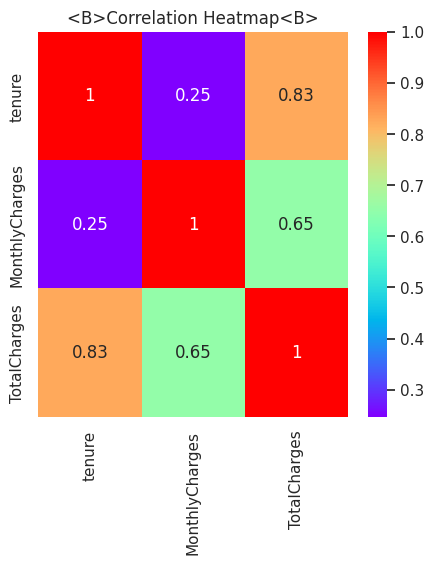

In [174]:
plt.figure(figsize=(5, 5))
num_df=df.select_dtypes(include=['number'])
sns.heatmap(num_df.corr(), annot=True, cmap='rainbow')
plt.title('<B>Correlation Heatmap<B>')
plt.show()

In [175]:
!pip install fg-data-profiling #highly popular automated data exploration library

In [176]:
from ydata_profiling import ProfileReport

In [177]:
profile=ProfileReport(df,title="Samarth_new_report1",explorative=True)
profile.to_file("Samarth_new_report2.html")  #near dataset u will find ur report download and view it

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 20/20 [00:01<00:00, 16.38it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

## Now Random forest part starts training and testing

In [178]:
df2=df

In [179]:
le=LabelEncoder()
for col in df.columns:
  if df[col].dtypes=='object':
    df[col]=le.fit_transform(df[col])

In [180]:
#dropped PhoneService and gender because they had negligible correlation with Churn
x=df.drop(columns=['Churn','PhoneService','gender'])
y=df['Churn'].values
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,0,1,0,1,0,1,0,0,2,0,0,0,0,0,1,2,29.85,29.85,0
1,1,0,0,0,34,1,0,0,2,0,2,0,0,0,1,0,3,56.95,1889.50,0
2,1,0,0,0,2,1,0,0,2,2,0,0,0,0,0,1,3,53.85,108.15,1
3,1,0,0,0,45,0,1,0,2,0,2,2,0,0,1,0,0,42.30,1840.75,0
4,0,0,0,0,2,1,0,1,0,0,0,0,0,0,0,1,2,70.70,151.65,1


In [181]:
x

,SeniorCitizen,Partner,Dependents,tenure,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
0,0,1,0,1,1,0,0,2,0,0,0,0,0,1,2,29.85,29.85
1,0,0,0,34,0,0,2,0,2,0,0,0,1,0,3,56.95,1889.50
2,0,0,0,2,0,0,2,2,0,0,0,0,0,1,3,53.85,108.15
3,0,0,0,45,1,0,2,0,2,2,0,0,1,0,0,42.30,1840.75
4,0,0,0,2,0,1,0,0,0,0,0,0,0,1,2,70.70,151.65
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,0,1,1,24,2,0,2,0,2,2,2,2,1,1,3,84.80,1990.50
7039,0,1,1,72,2,1,0,2,2,0,2,2,1,1,1,103.20,7362.90
7040,0,1,1,11,1,0,2,0,0,0,0,0,0,1,2,29.60,346.45
7041,1,1,0,4,2,1,0,0,0,0,0,0,0,1,3,74.40,306.60


In [182]:
y

array([0, 0, 1, ..., 0, 1, 0])

In [183]:
from sklearn.model_selection import train_test_split

In [184]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.25,random_state=1)

In [185]:
df

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,0,1,0,1,0,1,0,0,2,0,0,0,0,0,1,2,29.85,29.85,0
1,1,0,0,0,34,1,0,0,2,0,2,0,0,0,1,0,3,56.95,1889.50,0
2,1,0,0,0,2,1,0,0,2,2,0,0,0,0,0,1,3,53.85,108.15,1
3,1,0,0,0,45,0,1,0,2,0,2,2,0,0,1,0,0,42.30,1840.75,0
4,0,0,0,0,2,1,0,1,0,0,0,0,0,0,0,1,2,70.70,151.65,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,1,0,1,1,24,1,2,0,2,0,2,2,2,2,1,1,3,84.80,1990.50,0
7039,0,0,1,1,72,1,2,1,0,2,2,0,2,2,1,1,1,103.20,7362.90,0
7040,0,0,1,1,11,0,1,0,2,0,0,0,0,0,0,1,2,29.60,346.45,0
7041,1,1,1,0,4,1,2,1,0,0,0,0,0,0,0,1,3,74.40,306.60,1


In [186]:
x_train.shape

(5274, 17)

In [187]:
x_test.shape

(1758, 17)

In [188]:
num_cols=['TotalCharges','MonthlyCharges','tenure']

In [189]:
scalar=StandardScaler()  #generally used when ur data set have outliers in them

x_train[num_cols]=scalar.fit_transform(x_train[num_cols])
x_test[num_cols]=scalar.transform(x_test[num_cols])

In [190]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn import metrics
from sklearn.metrics import *

creating the model of random forest

In [191]:
model_rf=RandomForestClassifier(n_estimators=100,random_state=65,n_jobs=-1,class_weight='balanced_subsample')

train the model

In [192]:
model_rf.fit(x_train,y_train)

RandomForestClassifier(class_weight='balanced_subsample', n_jobs=-1,
                       random_state=65)

making predictions

In [193]:
y_pred=model_rf.predict(x_test)

checking accuracy

In [194]:
print(accuracy_score(y_pred,y_test))

0.7918088737201365


finding the feature importance

In [195]:
importance_df = pd.DataFrame({
    'Feature': x_train.columns,
    'Importance': model_rf.feature_importances_
}).sort_values(by='Importance', ascending=False)

print(importance_df)

             Feature  Importance
16      TotalCharges    0.179120
15    MonthlyCharges    0.170894
3             tenure    0.153934
12          Contract    0.118812
6     OnlineSecurity    0.055753
14     PaymentMethod    0.049804
9        TechSupport    0.044648
5    InternetService    0.032879
7       OnlineBackup    0.027418
8   DeviceProtection    0.026355
13  PaperlessBilling    0.023662
4      MultipleLines    0.022255
1            Partner    0.021512
2         Dependents    0.018953
0      SeniorCitizen    0.018650
11   StreamingMovies    0.018451
10       StreamingTV    0.016899


In [196]:
#overall summary of the model's predictive performance
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.83      0.90      0.86      1294
           1       0.64      0.48      0.55       464

    accuracy                           0.79      1758
   macro avg       0.74      0.69      0.71      1758
weighted avg       0.78      0.79      0.78      1758



In [203]:
# Picking any customer from the test set (change the number to try different ones)
customer_number = 4

# Showing their original details (before encoding, human-readable)
print("Customer details:")
print(df_readable.loc[x_test.index[customer_number]])# Get the model's prediction for this customer
sample = x_test.iloc[[customer_number]]
prediction = model_rf.predict(sample)[0]
probability = model_rf.predict_proba(sample)[0][1]

print("\n--- MODEL PREDICTION ---")
print("Predicted:", "Churn" if prediction == 1 else "No Churn")
print(f"Confidence (churn probability): {probability:.0%}")

# Showing what actually happened (the real answer)
actual = y_test[customer_number]
print("Actual result:", "Churn" if actual == 1 else "No Churn")

Customer details:
customerID                9625-QSTYE
gender                        Female
SeniorCitizen                      0
Partner                           No
Dependents                        No
tenure                            13
PhoneService                     Yes
MultipleLines                     No
InternetService          Fiber optic
OnlineSecurity                    No
OnlineBackup                     Yes
DeviceProtection                 Yes
TechSupport                       No
StreamingTV                       No
StreamingMovies                   No
Contract              Month-to-month
PaperlessBilling                 Yes
PaymentMethod       Electronic check
MonthlyCharges                 81.15
TotalCharges                   952.3
Churn                            Yes
Name: 927, dtype: object

--- MODEL PREDICTION ---
Predicted: Churn
Confidence (churn probability): 83%
Actual result: Churn
